### Functions

In [3]:
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from scipy.interpolate import interp1d
import scipy.integrate as integrate
from scipy.optimize import curve_fit

### ---------- RI Calibration Curve

## Inital Dataset
mol_frac = np.array([0, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 1])
ri = np.array([1.37250, 1.37000, 1.36750, 1.36450, 1.35800,
               1.35500, 1.35000, 1.34600, 1.33850, 1.33450, 1.32350])
ri_err = 1e-3
ri_errs = np.full_like(ri, ri_err)

# Polynomial function
def ri_FIND(x, a, b, c):
    return a * x**2 + b * x + c

# Curve fit with uncertainties
params, cov = curve_fit(ri_FIND, mol_frac, ri, sigma=ri_errs, absolute_sigma=True)

a, b, c = params

def mf_FIND(ri_val, ri_err=1e-3):
    # Backsolve for mole fraction
    coeffs = [a, b, c - ri_val]
    roots = np.roots(coeffs)
    
    # Select valid roots
    valid_roots = roots[np.isreal(roots) & (roots >= 0) & (roots <= 1)].real
    if len(valid_roots) == 0:
        return np.nan, np.nan
    x = valid_roots[0] 
    
    # Error from parameter uncertainties using covariance matrices
    sqrt_part = np.sqrt(b**2 - 4*a*(c - ri_val))
    dx_da = (b - sqrt_part)/(2*a)**2 + (c - ri_val)/(a*sqrt_part)
    dx_db = (-1 + b/sqrt_part)/(2*a)
    dx_dc = 1/sqrt_part
    
    var_x_params = (dx_da**2 * cov[0,0] + 
                   dx_db**2 * cov[1,1] + 
                   dx_dc**2 * cov[2,2] +
                   2*dx_da*dx_db*cov[0,1] +
                   2*dx_da*dx_dc*cov[0,2] +
                   2*dx_db*dx_dc*cov[1,2])
    
    # Total error
    total_error = var_x_params
    
    return x, total_error

## -----------------------------------
    
def VLE_solve(x): 
  T = 72
  G12 = 1.689
  G21 = 0.5445
  x2 = 1-x
  R1 = x + x2*G12
  R2 = x2 + x*G21

  P1_MeOH = 0.00131579 * (10**(7.87863 - 1473.11 / (T + 230.0)))
  P2_IPA = 0.00131579 * (10**(6.66040 - 813.055 / (T + 132.93)))

  gamma1 = math.exp(-math.log(R1) + x2*((G12/R1) - (G21/R2)))
  gamma2 = math.exp(-math.log(R2) - x*((G12/R1) - (G21/R2)))

  P_total = x * gamma1 * P1_MeOH + x2 * gamma2 * P2_IPA

  y = x*(P1_MeOH/P_total)*gamma1
  return y

## -------------------------------------------

def VLE_invert(y_target):
    x_low=0.0
    x_high=1.0
    func = lambda x: VLE_solve(x) - y_target
    x_solution = brentq(func, x_low, x_high)
    return x_solution
    
## -------------------------------------------

def stepDown_solve(xB, xD, R, eta, meff):
    max_steps = 1000
    current_x = xD # Set x to distillate comp
    N_stages = 0
    mccabe = []
    tol = 1e-6
    if R == 'total':
        while N_stages < max_steps:
            y_op = current_x
            mccabe.append((current_x, y_op))
            x = VLE_invert(y_op)
            x_real = eta * x + (1 - eta) * current_x
            current_x = x_real
            N_stages += 1
            if current_x <= xB:  # Stop when we reach or exceed xB
                current_y = current_x
                mccabe.append((current_x, current_y))
                break
    else:   
        while N_stages < max_steps:
            y_op = ((R / (R + 1)) * current_x) + (xD / (R + 1))
            mccabe.append((current_x, y_op))
            try:
                x = VLE_invert(y_op)
            except ValueError:
                break  # or `x = current_x` or `continue`
            
            if N_stages < 11:
                x_real = eta * x + (1 - eta) * current_x
            else:
                x_real = meff * x + (1 - eta) * current_x
                
            current_x = x_real
            N_stages += 1
            if current_x <= xB:  # Stop when we reach or exceed xD
                current_y = ((R / (R + 1)) * current_x) + (xD / (R + 1))
                mccabe.append((current_x, current_y))
                break

    return mccabe, N_stages

## -------------------------------------------

def weighted_avg(xMeOH, xIPA):
    molar_density = (xMeOH*0.02472) + (xIPA*0.01308)
    return molar_density

# Refractive Index Stuff

#### Refractive Index vs Mol Fraction Calculator

In [6]:
values = [1.326, 1.3265, 1.3295, 1.3315, 1.3665, 1.366]

# Process each value
for ri_val in values:
    mf_pred, mf_err = mf_FIND(ri_val)
    print(f"{mf_pred:.2f} ± {mf_err:.2f}")

0.99 ± 0.08
0.98 ± 0.08
0.94 ± 0.07
0.91 ± 0.07
0.22 ± 0.03
0.24 ± 0.03


#### Refractive Index vs Mol Fraction Plot

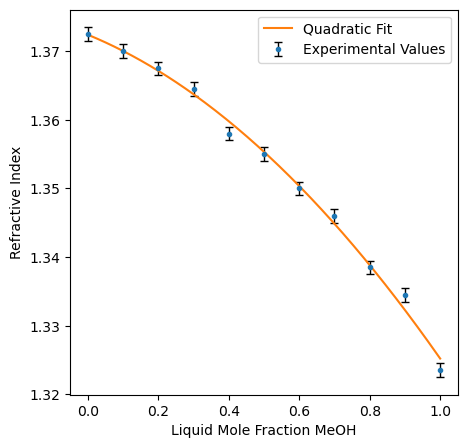

In [8]:
# Plot the fit
plt.figure(figsize=(5,5))
plt.errorbar(mol_frac, ri, yerr=1e-3, fmt='o', ms=3, capsize=3, elinewidth=1, ecolor='black', label='Experimental Values')
x_vals = np.linspace(0,1,200)
plt.plot(x_vals, ri_FIND(x_vals, *params), label='Quadratic Fit')
plt.xlabel('Liquid Mole Fraction MeOH')
plt.ylabel('Refractive Index')
plt.legend()
plt.savefig('RI_calibration.png', dpi=300, bbox_inches='tight')  # Save BEFORE show
plt.show()

# McCabe-Thiele

## Total Reflux

### Solve for efficiencies across 3 power levels

In [12]:
pots = [1.367, 1.367, 1.366]
LT = [1.360, 1.359, 1.358]
dist = [0.99, 0.98, 0.99]

meffords = []
merrs = []
effcs = []

for i in range(len(pots)):
    pot, sigma_W = mf_FIND(pots[i])
    last_tray, sigma_L = mf_FIND(LT[i])

    y_pot = VLE_solve(pot)
    y_last = VLE_solve(last_tray)
    y_eq = VLE_solve(0.20)
    
    meff = (y_pot - y_last)/(y_eq - y_last)
    meffords.append(meff)

    term1 = sigma_L*((y_pot - y_eq)/(y_eq- y_last)**2)
    term2 = sigma_W/(y_eq - y_last)
    sigma_M = math.sqrt(term1**2 + term2**2)
    merrs.append(sigma_M)
    
    result = stepDown_solve(pot, dist[i], 'total', 1, 1)
    effcs.append((result[1]-1)/10)
    
print(meffords)
print(merrs)
print(effcs)

[0.9735475993041719, 0.9760275725743142, 0.8319290326964917]
[0.13871483362161088, 0.12570078234224463, 0.1227210128215731]
[0.8, 0.7, 0.7]


### Modeled still pot values for 3 power levels

In [14]:
dist = [0.99, 0.98, 0.99]
Still_Pot = []

for i in range(len(dist)):
    result = stepDown_solve(0, dist[i], 'total', effcs[i], meffords[i])
    answer = result[0]
    xW = round(answer[11][0], 4)
    Still_Pot.append(xW)

print(Still_Pot)

[0.1291, 0.1444, 0.2167]


In [49]:
### Interpolations
eff = np.mean(effcs)
meff = np.mean(meffords)


    

## ------------

feed = [0.20, 0.20, 0.24]
xW = [0.13, 0.14, 0.22]
for i in range(len(feed)):
    guess = np.linspace(0.01, 0.99, 30)
    xB_result = []
    for j in guess:
        result = stepDown_solve(0.0, j, 'total', effcs[i], meffords[i]) 
        pred_mct = result[0]
        xB_result.append(pred_mct[11][0])
    
    xD_solve = interp1d(xB_result, guess, kind='linear', fill_value='extrapolate')
    xF = feed[i]
    F = 850*weighted_avg(xF, (1-xF))
    guess_final = xW[i]
    result = integrate.quad(lambda x: 1/(xD_solve(x)-x), xF, guess_final)
    W = F*math.exp(result[0])
    Avg_d = (F*xF - W*guess_final)/(F-W)
    print(F, W, Avg_d)

13.096800000000002 12.049192289686992 1.0051138340954757
13.096800000000002 12.158987616656363 0.9779159989318029
13.49256 13.143688314100894 0.9934969930407059


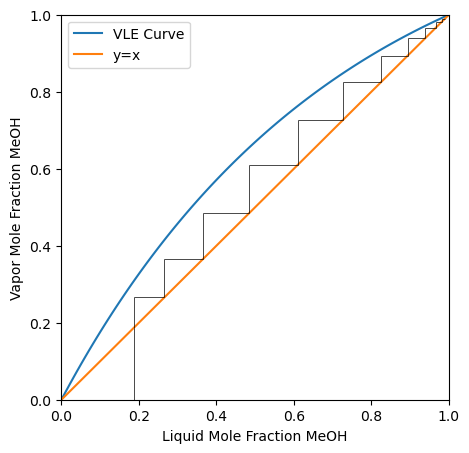

11


In [16]:
x_vals = np.linspace(0, 1, 100)
y_vals = [VLE_solve(x) for x in x_vals]

result = stepDown_solve(0.21, 0.99, 'total', 0.73, 0.93)
mccabe = result[0]
# Plotting
plt.figure(figsize=(5,5))
plt.plot(x_vals, y_vals, label='VLE Curve')
plt.plot(x_vals, x_vals, label='y=x')

endpt = len(mccabe)-1
for i in range(endpt):
    plt.hlines(mccabe[i][1], mccabe[i][0], mccabe[i+1][0], colors='black', linestyles='solid', linewidth=0.5)
    plt.vlines(mccabe[i+1][0], mccabe[i][1], mccabe[i+1][1], colors='black', linestyles='solid', linewidth=0.5)
plt.vlines(x=mccabe[endpt][1], ymin=0, ymax=mccabe[endpt][1], colors='black', linestyles='solid', linewidth=0.5)

plt.xlabel('Liquid Mole Fraction MeOH')
plt.ylabel('Vapor Mole Fraction MeOH')
plt.legend()
ax = plt.gca()
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
## plt.text(0.05, 0.8, "126 ± 2 W", fontsize=12, color='black')
plt.savefig('total_reflux_AVG.png', dpi=300, bbox_inches='tight')
plt.show()

theoretical_stages = result[1]
print(theoretical_stages)

### Rayleigh

In [45]:
### Interpolations
eff = np.mean(effcs)
meff = np.mean(meffords)
guess = np.linspace(0.01, 0.99, 50)
xB_result = []
    
for i in guess:
    result = stepDown_solve(0.0, i, 5, eff, meff) 
    pred_mct = result[0]
    xB_result.append(pred_mct[11][0])
    
xD_solve = interp1d(xB_result, guess, kind='linear', fill_value='extrapolate')
## ------------

xF = 0.2352
F = 900*weighted_avg(xF, (1-xF))
guess_final = 0.2201
result = integrate.quad(lambda x: 1/(xD_solve(x)-x), xF, guess_final)
W = F*math.exp(result[0])
Avg_d = (F*xF - W*guess_final)/(F-W)

print(F, W, Avg_d)

14.2359552 13.921002973236039 0.9026254919727974


### R = 5

The predicted mole fraction of MeOH in the charge is 0.234 when the distillate is 0.911


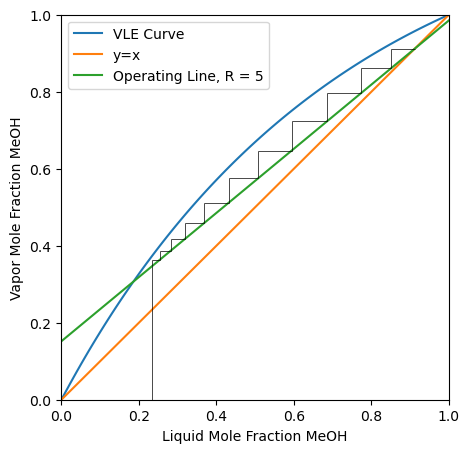

In [20]:
xD_in = 0.9115

result_2 = stepDown_solve(0.0, xD_in, 5, eff, meff)
pred_mct_2 = result_2[0]

print(f'The predicted mole fraction of MeOH in the charge is {pred_mct_2[11][0]:.3f} when the distillate is {xD_in:.3f}')

plt.figure(figsize=(5,5))
plt.plot(x_vals, y_vals, label='VLE Curve')
plt.plot(x_vals, x_vals, label='y=x')
op_line = (5/6)*x_vals + xD_in/6
plt.plot(x_vals, op_line, label='Operating Line, R = 5')

for i in range(11):
    plt.hlines(pred_mct_2[i][1], pred_mct_2[i][0], pred_mct_2[i+1][0], colors='black', linestyles='solid', linewidth=0.5)
    plt.vlines(pred_mct_2[i+1][0], pred_mct_2[i][1], pred_mct_2[i+1][1], colors='black', linestyles='solid', linewidth=0.5)
plt.vlines(x=pred_mct_2[11][0], ymin=0, ymax=pred_mct_2[11][1], colors='black', linestyles='solid', linewidth=0.5)

plt.xlabel('Liquid Mole Fraction MeOH')
plt.ylabel('Vapor Mole Fraction MeOH')
plt.legend()
plt.xlim([0, 1])
plt.ylim([0, 1])

plt.savefig('mccabe_thiele_R_5.png', dpi=300, bbox_inches='tight')
plt.show()

### Modeled still pot values for each distillate sample

In [22]:
dist = [0.99,0.98,0.94,0.91]
Still_Pot = []

for i in range(len(dist)):
    result = stepDown_solve(0, dist[i], 5, eff, meff)
    answer = result[0]
    xW = round(answer[11][0], 4)
    Still_Pot.append(xW)

print(Still_Pot)

[0.4505, 0.3632, 0.2626, 0.2328]
